# Task 2 · Unemployment Analysis in India

**Question:** How did recorded unemployment vary across Indian states and months, especially around the first COVID-19 lockdown?

**Source:** [Unemployment in India, Kaggle](https://www.kaggle.com/datasets/gokulrajkmv/unemployment-in-india). Download the dataset and put `Unemployment in India.csv` in the same folder as this notebook. The dataset contains state, date, area (rural/urban), estimated unemployment rate, estimated employed people, and estimated labour participation rate. Coverage is approximately May 2019–June 2020; confirm the actual dates below. No Kaggle API key is required after downloading the CSV.

**Method:** Each row is a state–area–month observation. We first average rural and urban rates within each state and month, then average across states, so a state with two records does not count twice when another has one. These are **unweighted averages of reported rates**, not official population-weighted national estimates. The source has no employment-rate field: where needed, we *derive* employment-to-population rate as `labour participation rate × (1 − unemployment rate / 100)`. This is distinct from the dataset's estimated number employed.


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", 20)

path = Path("Unemployment in India.csv")
if not path.exists():
    raise FileNotFoundError(
        "Download 'Unemployment in India.csv' from the Kaggle link above "
        "and place it beside this notebook."
    )
raw = pd.read_csv(path)
print("Raw shape:", raw.shape)
display(raw.head())
print("Raw column types:\n", raw.dtypes)
print("Raw missing values:\n", raw.isna().sum())


Raw shape: (768, 7)


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


Raw column types:
 Region                                       object
 Date                                        object
 Frequency                                   object
 Estimated Unemployment Rate (%)            float64
 Estimated Employed                         float64
 Estimated Labour Participation Rate (%)    float64
Area                                         object
dtype: object
Raw missing values:
 Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64


## Cleaning and coverage

Whitespace in the Kaggle headings and state names is removed. Missing rates/dates/regions are excluded from rate comparisons. Date parsing uses day–month–year. Before interpreting any comparison, inspect month coverage and missing state–month combinations.


In [2]:
# Standardize source headings without depending on their leading spaces.
df = raw.copy()
df.columns = df.columns.str.strip().str.replace(r"\s+", " ", regex=True)
df = df.rename(columns={
    "Region": "state", "Date": "date", "Area": "area",
    "Estimated Unemployment Rate (%)": "unemployment_rate",
    "Estimated Labour Participation Rate (%)": "labour_participation_rate",
    "Estimated Employed": "estimated_employed",
    "Frequency": "frequency",
})
required = ["state", "date", "unemployment_rate", "labour_participation_rate"]
missing_columns = set(required) - set(df.columns)
if missing_columns:
    raise ValueError(f"Missing required columns: {sorted(missing_columns)}. Found: {df.columns.tolist()}")

df["state"] = df["state"].astype("string").str.strip()
if "area" in df:
    df["area"] = df["area"].astype("string").str.strip()
df["date"] = pd.to_datetime(df["date"].astype("string").str.strip(),
                            format="%d-%m-%Y", errors="coerce")
for col in ["unemployment_rate", "labour_participation_rate", "estimated_employed"]:
    if col in df:
        df[col] = pd.to_numeric(df[col], errors="coerce")
print("Missing values after conversion:\n", df[required].isna().sum())
df = df.dropna(subset=required).copy()
df = df[df["state"].ne("").fillna(False)].copy()
df["month"] = df["date"].dt.to_period("M").dt.to_timestamp()
df["employment_rate"] = df["labour_participation_rate"] * (1 - df["unemployment_rate"] / 100)
keys = ["state", "month"] + (["area"] if "area" in df else [])
print("Duplicate state/month/area rows:", df.duplicated(keys).sum())
print("Clean shape:", df.shape, "| States:", df.state.nunique())
print("Date range:", df.date.min().date(), "to", df.date.max().date())
display(df.groupby("month").agg(records=("state", "size"), states=("state", "nunique")))
display(df.head())

# Use one state/month record for comparisons and charts.
state_month = (df.groupby(["state", "month"], as_index=False)
               [["unemployment_rate", "employment_rate", "labour_participation_rate"]]
               .mean())


Missing values after conversion:
 state                        28
date                         28
unemployment_rate            28
labour_participation_rate    28
dtype: int64
Duplicate state/month/area rows: 0
Clean shape: (740, 9) | States: 28
Date range: 2019-05-31 to 2020-06-30


,records,states
month,,
2019-05-01,54,28
2019-06-01,54,28
2019-07-01,54,28
2019-08-01,53,28
2019-09-01,52,27
2019-10-01,55,28
2019-11-01,55,28
2019-12-01,53,28
2020-01-01,53,27


,state,date,frequency,unemployment_rate,estimated_employed,labour_participation_rate,area,month,employment_rate
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural,2019-05-01,41.661740
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural,2019-06-01,40.767475
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural,2019-07-01,41.868750
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural,2019-08-01,42.510196
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural,2019-09-01,42.370044


## Region-wise average unemployment

The table ranks states by their mean rate across available months; this ranking depends on the observed date coverage. The chart shows the ten highest, not the largest labour forces.


,average_unemployment_rate_pct
state,
Tripura,28.35
Haryana,26.28
Jharkhand,20.58
Bihar,18.92
Himachal Pradesh,18.54
Delhi,16.50
Chandigarh,15.99
Jammu & Kashmir,15.72
Rajasthan,14.06


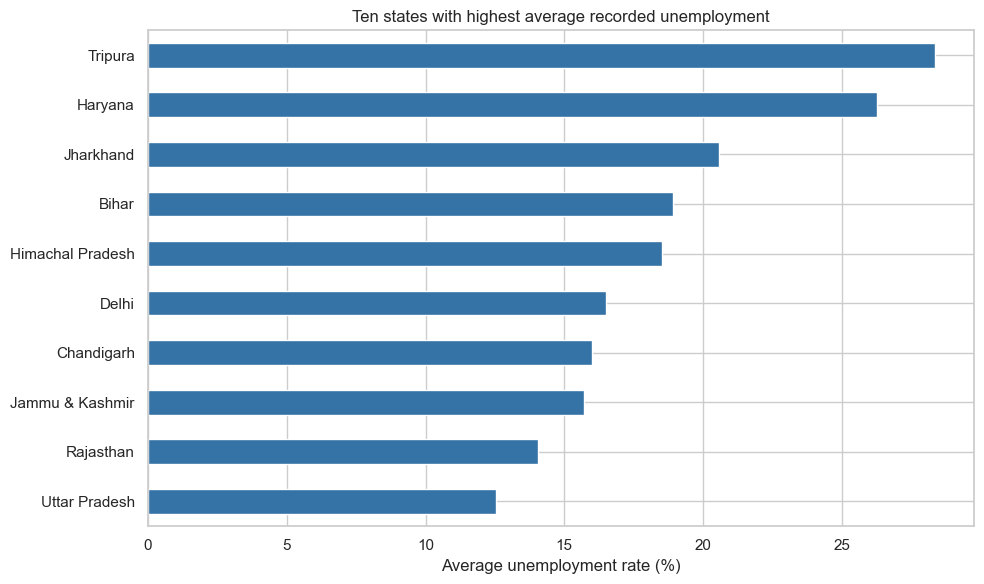

**Observation:** Tripura has the highest average recorded rate (28.35%) in this dataset. This is an average of available monthly rates; differing month coverage can affect the ranking.

In [3]:
state_avg = state_month.groupby("state")["unemployment_rate"].mean().sort_values(ascending=False)
display(state_avg.rename("average_unemployment_rate_pct").round(2).to_frame())
top10 = state_avg.head(10).sort_values()
fig, ax = plt.subplots(figsize=(10, 6))
top10.plot.barh(ax=ax, color="#3572A5")
ax.set(title="Ten states with highest average recorded unemployment", xlabel="Average unemployment rate (%)", ylabel="")
plt.tight_layout()
plt.show()
display(Markdown(f"**Observation:** {state_avg.index[0]} has the highest average recorded rate "
                 f"({state_avg.iloc[0]:.2f}%) in this dataset. This is an average of available "
                 "monthly rates; differing month coverage can affect the ranking."))


## Monthly trend

The next line averages available state-month unemployment rates for each month. Read changes alongside the number of reporting states above; these values are not an official all-India unemployment series.


,mean_state_unemployment_pct
month,
2019-05-01,9.03
2019-06-01,9.33
2019-07-01,9.15
2019-08-01,9.58
2019-09-01,9.18
2019-10-01,9.97
2019-11-01,10.09
2019-12-01,9.35
2020-01-01,10.14


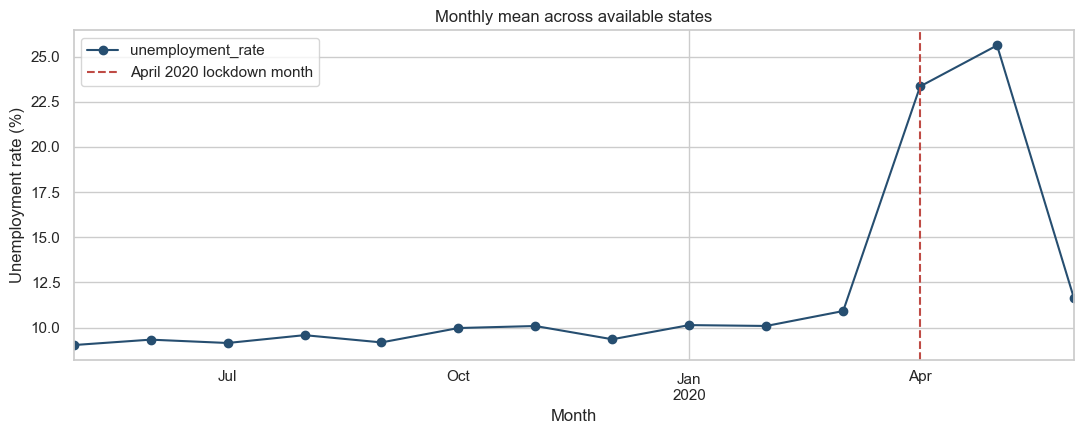

**Observation:** The highest recorded monthly mean is **25.62%** in **May 2020**. The line shows association in time, not a causal estimate.

In [4]:
monthly = state_month.groupby("month")["unemployment_rate"].mean()
display(monthly.rename("mean_state_unemployment_pct").round(2).to_frame())
fig, ax = plt.subplots(figsize=(11, 4.5))
monthly.plot(ax=ax, marker="o", color="#264E70")
ax.axvline(pd.Timestamp("2020-04-01"), color="#BF4B45", linestyle="--", label="April 2020 lockdown month")
ax.set(title="Monthly mean across available states", xlabel="Month", ylabel="Unemployment rate (%)")
ax.legend()
plt.tight_layout()
plt.show()
peak_month = monthly.idxmax()
display(Markdown(f"**Observation:** The highest recorded monthly mean is **{monthly.max():.2f}%** "
                 f"in **{peak_month:%B %Y}**. The line shows association in time, not a causal estimate."))


## Three major states over time

Maharashtra, Uttar Pradesh, and Tamil Nadu are plotted as separate state-month series. Missing months remain gaps rather than invented values.


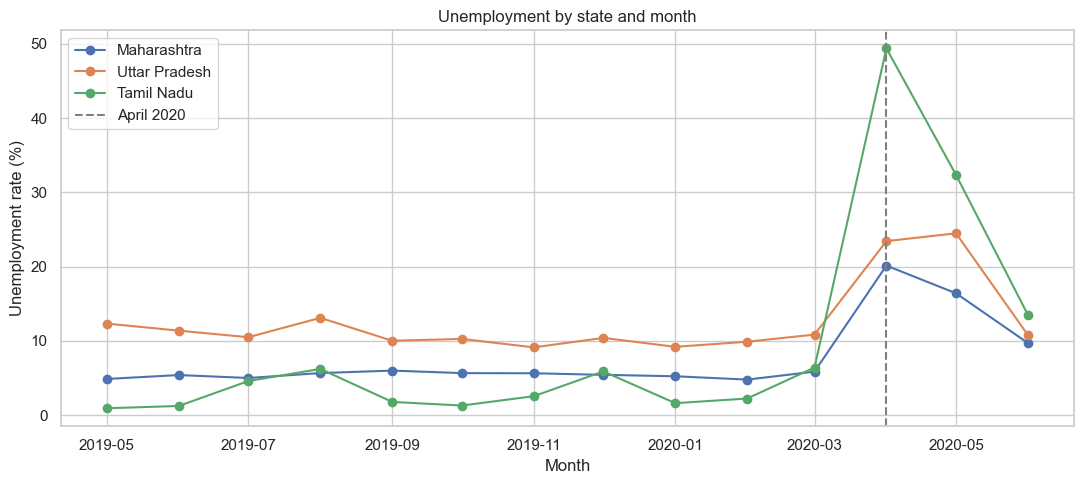

**Maharashtra:** The observed peak is **20.14%** in **April 2020**. Compare its curve with the other states and note any missing months.

**Uttar Pradesh:** The observed peak is **24.48%** in **May 2020**. Compare its curve with the other states and note any missing months.

**Tamil Nadu:** The observed peak is **49.37%** in **April 2020**. Compare its curve with the other states and note any missing months.

In [5]:
selected = ["Maharashtra", "Uttar Pradesh", "Tamil Nadu"]
absent = set(selected) - set(state_month.state)
if absent:
    raise ValueError(f"Selected states missing from source: {sorted(absent)}")
fig, ax = plt.subplots(figsize=(11, 5))
for state in selected:
    series = state_month.loc[state_month.state.eq(state)].set_index("month")["unemployment_rate"].sort_index()
    ax.plot(series.index, series.values, marker="o", label=state)
ax.axvline(pd.Timestamp("2020-04-01"), color="grey", linestyle="--", label="April 2020")
ax.set(title="Unemployment by state and month", xlabel="Month", ylabel="Unemployment rate (%)")
ax.legend()
plt.tight_layout()
plt.show()
for state in selected:
    s = state_month.loc[state_month.state.eq(state)].set_index("month")["unemployment_rate"]
    display(Markdown(f"**{state}:** The observed peak is **{s.max():.2f}%** in **{s.idxmax():%B %Y}**. "
                     "Compare its curve with the other states and note any missing months."))


## Correlation of three rates

Employment rate below is derived from the other two columns, so correlations involving it are partly mathematical. Correlation does not establish causation.


,unemployment_rate,employment_rate,labour_participation_rate
unemployment_rate,1.000,-0.578,-0.006
employment_rate,-0.578,1.000,0.810
labour_participation_rate,-0.006,0.810,1.000


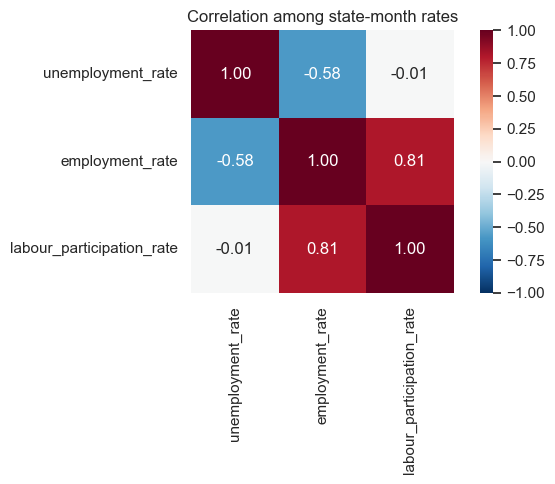

**Observation:** Unemployment and derived employment rates have correlation **-0.58**; the shared formula contributes to this relationship. State-month records are equally weighted.

In [6]:
columns = ["unemployment_rate", "employment_rate", "labour_participation_rate"]
corr = state_month[columns].corr()
display(corr.round(3))
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, ax=ax)
ax.set(title="Correlation among state-month rates")
plt.tight_layout()
plt.show()
display(Markdown(f"**Observation:** Unemployment and derived employment rates have "
                 f"correlation **{corr.loc['unemployment_rate', 'employment_rate']:.2f}**; "
                 "the shared formula contributes to this relationship. State-month records are equally weighted."))


## Before and after the first lockdown

**Pre period:** through February 2020. **Transition:** March 2020 excluded because restrictions began within the month. **Lockdown/early aftermath:** April 2020 onward in the available file. “Post” here means after the *onset* of restrictions, not after the pandemic ended. Different period lengths and coverage make this descriptive, not a causal impact estimate. Mean values are percentage levels; their difference is in **percentage points**.


In [7]:
pre = state_month[state_month.month < "2020-03-01"]
post = state_month[state_month.month >= "2020-04-01"]
if pre.empty or post.empty:
    raise ValueError("Both periods need observations; check the CSV and parsed dates.")
periods = pd.DataFrame({
    "Pre (through Feb 2020)": pre[columns].mean(),
    "April 2020 onward": post[columns].mean(),
})
periods["Change (percentage points)"] = periods.iloc[:, 1] - periods.iloc[:, 0]
display(periods.round(2))
print(f"Pre: {len(pre)} state-month rows across {pre.month.nunique()} months; "
      f"after onset: {len(post)} rows across {post.month.nunique()} months; March omitted.")
delta = periods.loc["unemployment_rate", "Change (percentage points)"]
display(Markdown(f"**Observation:** Mean recorded state-month unemployment changed by "
                 f"**{delta:+.2f} percentage points** from the pre period to April–June 2020 "
                 "(or the available final month). The timing is consistent with a lockdown shock, "
                 "but this comparison alone cannot isolate COVID-19's causal effect."))

# Matched-state check: only states present in both periods, so entry/exit matters less.
pre_state = pre.groupby("state")["unemployment_rate"].mean()
post_state = post.groupby("state")["unemployment_rate"].mean()
matched = pd.concat([pre_state.rename("pre"), post_state.rename("after_onset")], axis=1).dropna()
display(Markdown(f"**Coverage check:** {len(matched)} states appear in both periods; "
                 f"the mean of their within-state changes is "
                 f"**{(matched.after_onset - matched.pre).mean():+.2f} percentage points**."))


,Pre (through Feb 2020),April 2020 onward,Change (percentage points)
unemployment_rate,9.59,20.15,10.57
employment_rate,39.53,30.46,-9.07
labour_participation_rate,43.86,38.08,-5.78


Pre: 277 state-month rows across 10 months; after onset: 80 rows across 3 months; March omitted.


**Observation:** Mean recorded state-month unemployment changed by **+10.57 percentage points** from the pre period to April–June 2020 (or the available final month). The timing is consistent with a lockdown shock, but this comparison alone cannot isolate COVID-19's causal effect.

**Coverage check:** 28 states appear in both periods; the mean of their within-state changes is **+10.14 percentage points**.

## Conclusions and limits

The charts and generated observations describe variation in this Kaggle dataset. They should be interpreted using the printed coverage, because missing state-months, equal state weights, the short period after April 2020, and the derived employment rate limit generalization. No causal COVID effect or nationwide population-weighted rate is estimated. Run **Kernel → Restart & Run All** to regenerate every number and chart after changing the CSV.
